PHASE 5: SEGMENTATION & DEEP INSIGHTS (KMeans + Perception)
Total students: 225

──────────────────────────────────────────────────────────────────────
A. CONVERSION FUNNEL
──────────────────────────────────────────────────────────────────────
           Stage  Count     %  Drop_pct
  Total Students    225 100.0       0.0
Has Basic Skills    214  95.1       4.9
 Applied to Jobs    185  82.2      13.6
    Got Accepted     83  36.9      55.1


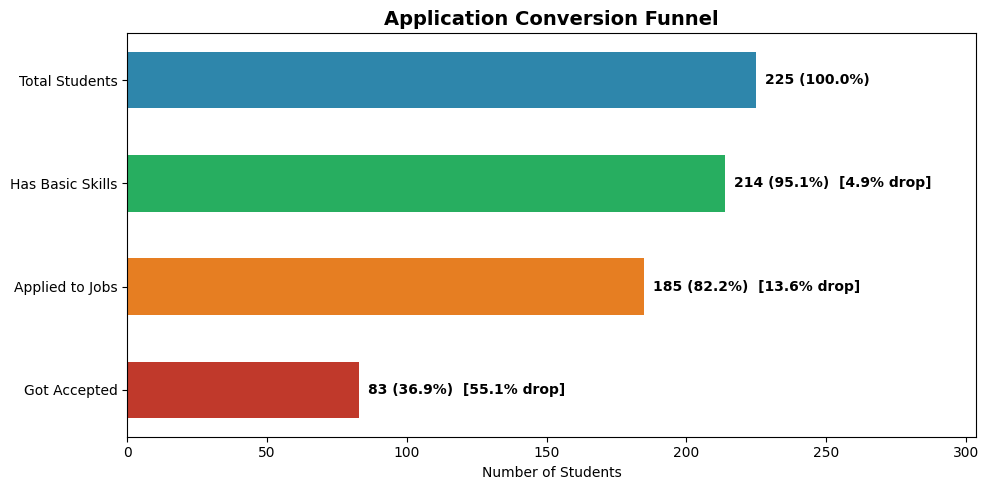

✅ conversion_funnel.png

──────────────────────────────────────────────────────────────────────
B. KMEANS CLUSTERING (Mutually Exclusive Segments)
──────────────────────────────────────────────────────────────────────

Cluster sizes:
cluster
0     36
1    100
2     20
3     69
Name: count, dtype: int64

CLUSTER PROFILES:

--- Cluster 0: The Seekers (Average Effort) ---
  Size: 36 (16.0%)
  Acceptance Rate: 36.1%
  Avg Hours: 6.8 | Avg Projects: 5.2
  Python: 77.8% | SQL: 88.9% | Excel: 94.4%
  Portfolio: 86.1% | Mentor: 75.0%
  Cairo: 50.0% | Events: 1.3

--- Cluster 1: The Seekers (Average Effort) ---
  Size: 100 (44.4%)
  Acceptance Rate: 39.0%
  Avg Hours: 5.7 | Avg Projects: 4.9
  Python: 80.0% | SQL: 94.0% | Excel: 99.0%
  Portfolio: 77.0% | Mentor: 70.0%
  Cairo: 51.0% | Events: 0.7

--- Cluster 2: The Seekers (Average Effort) ---
  Size: 20 (8.9%)
  Acceptance Rate: 35.0%
  Avg Hours: 3.6 | Avg Projects: 0.4
  Python: 30.0% | SQL: 35.0% | Excel: 0.0%
  Portfolio: 60.0% | Mentor:

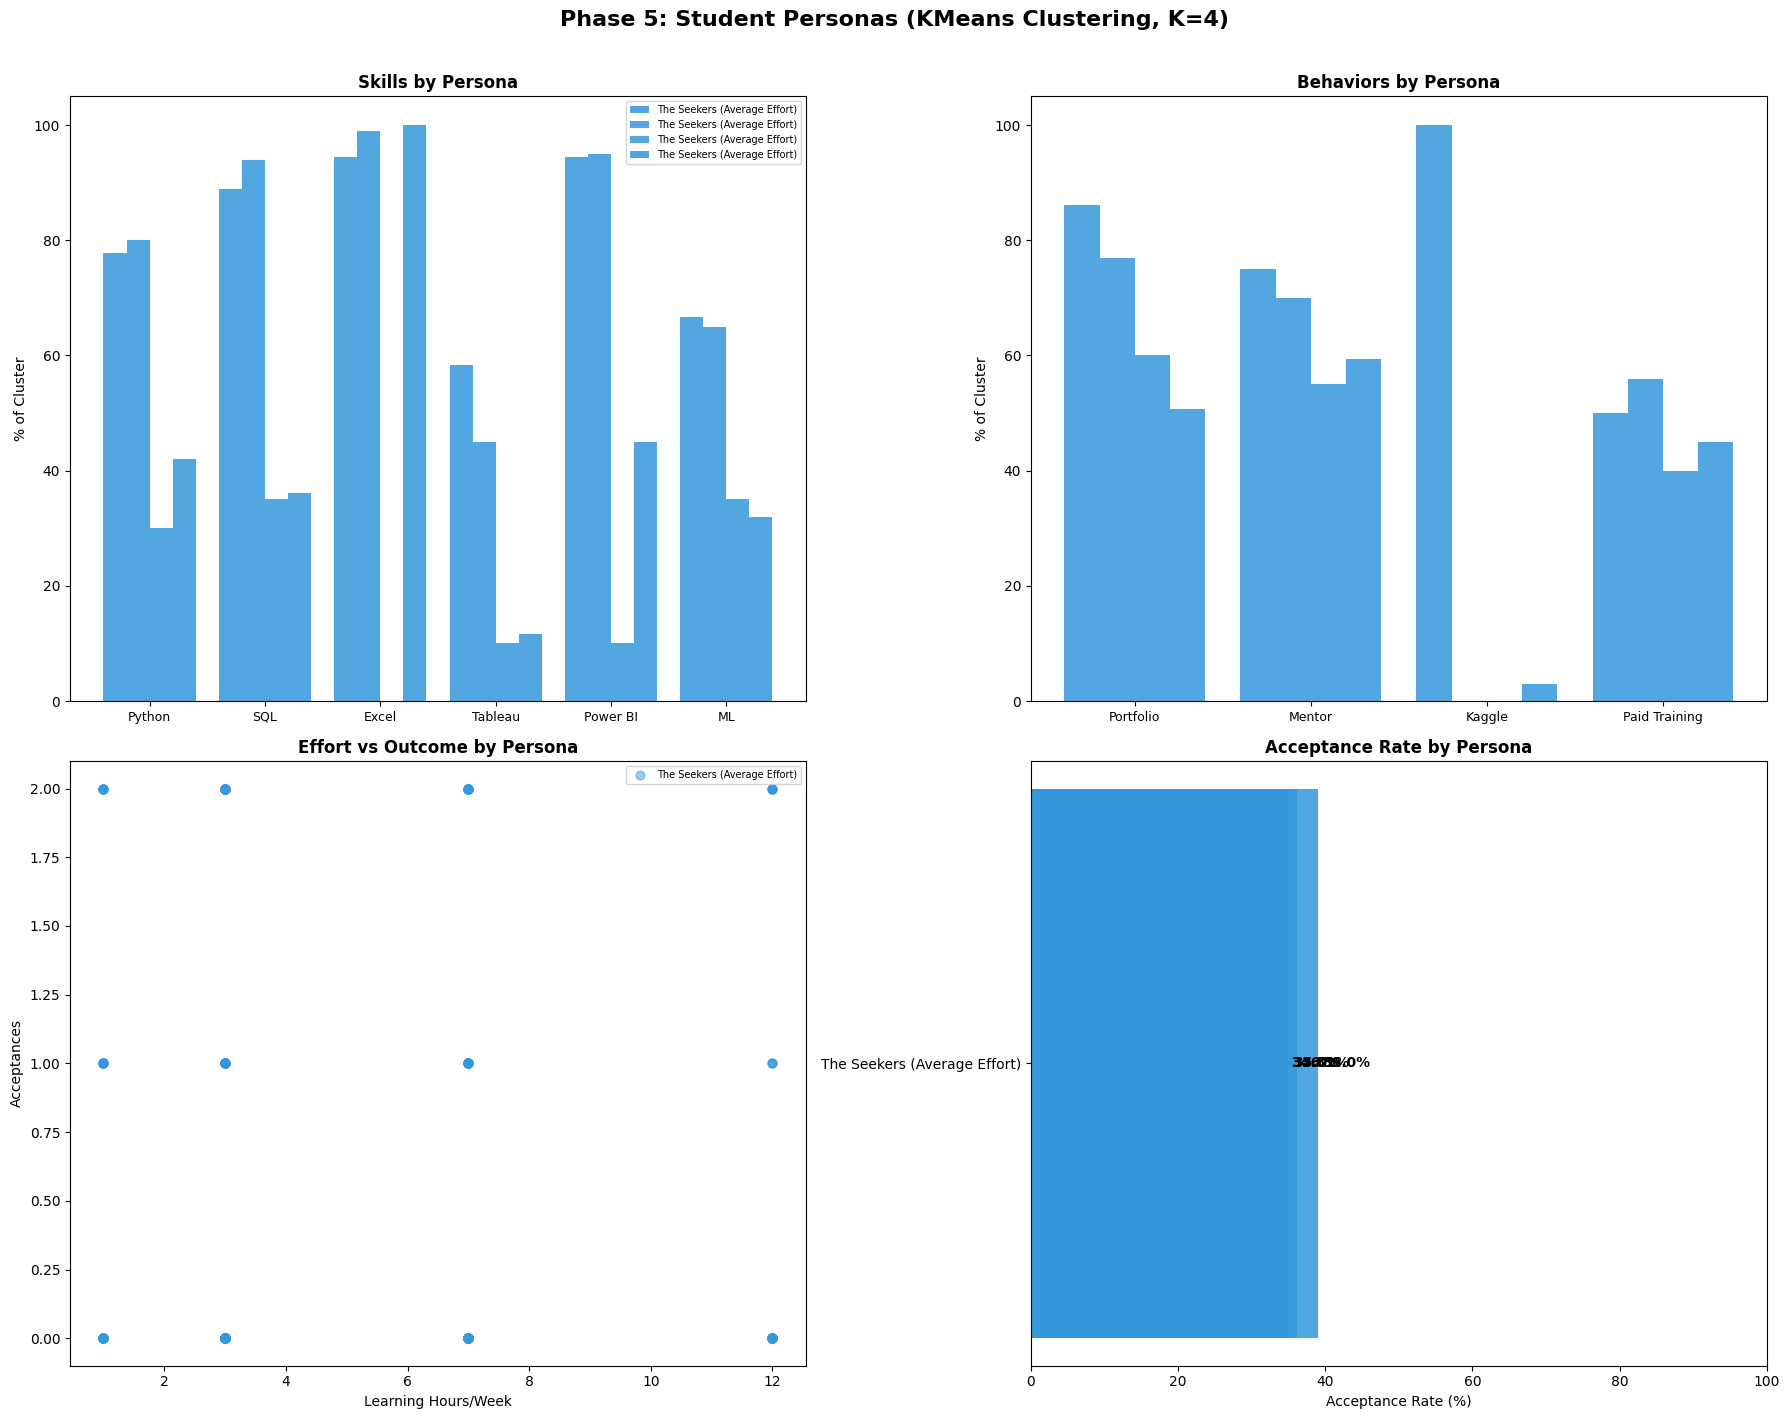

✅ segment_comparison.png

──────────────────────────────────────────────────────────────────────
D. PERCEPTION VS REALITY ANALYSIS
──────────────────────────────────────────────────────────────────────

--- Requirements Clarity ---
  [ 91] بتختلف من فرصة للتانية
  [ 71] واضحة لكن مش عارف أحدد موقفي
  [ 47] واضحة جدًا وعارف أقيس نفسي عليها
  [ 16] غير واضحة ومبهمة

--- Can Identify Gaps (Accepted vs Rejected) ---
  Accepted: Precise=39.8%, Approx=57.8%, No=2.4%
  Rejected (applicants): Precise=43.1%, Approx=52.0%, No=4.9%

--- Perceived Barriers (All Students) ---
  Technical Skills Gap: 87 (38.7%)
  Lack of Proven Experience: 144 (64.0%)
  Weak Self-Presentation: 55 (24.4%)
  Lack of Guidance: 71 (31.6%)
  High Competition: 131 (58.2%)
  University/Academic Background: 41 (18.2%)
  Limited Network: 95 (42.2%)

--- Frustration Sources ---
  No Response At All: 70 (31.1%)
  Rejection Without Reason: 42 (18.7%)
  High Competition: 58 (25.8%)
  Unclear/Too Many Requirements: 31 (13.8%)
  C

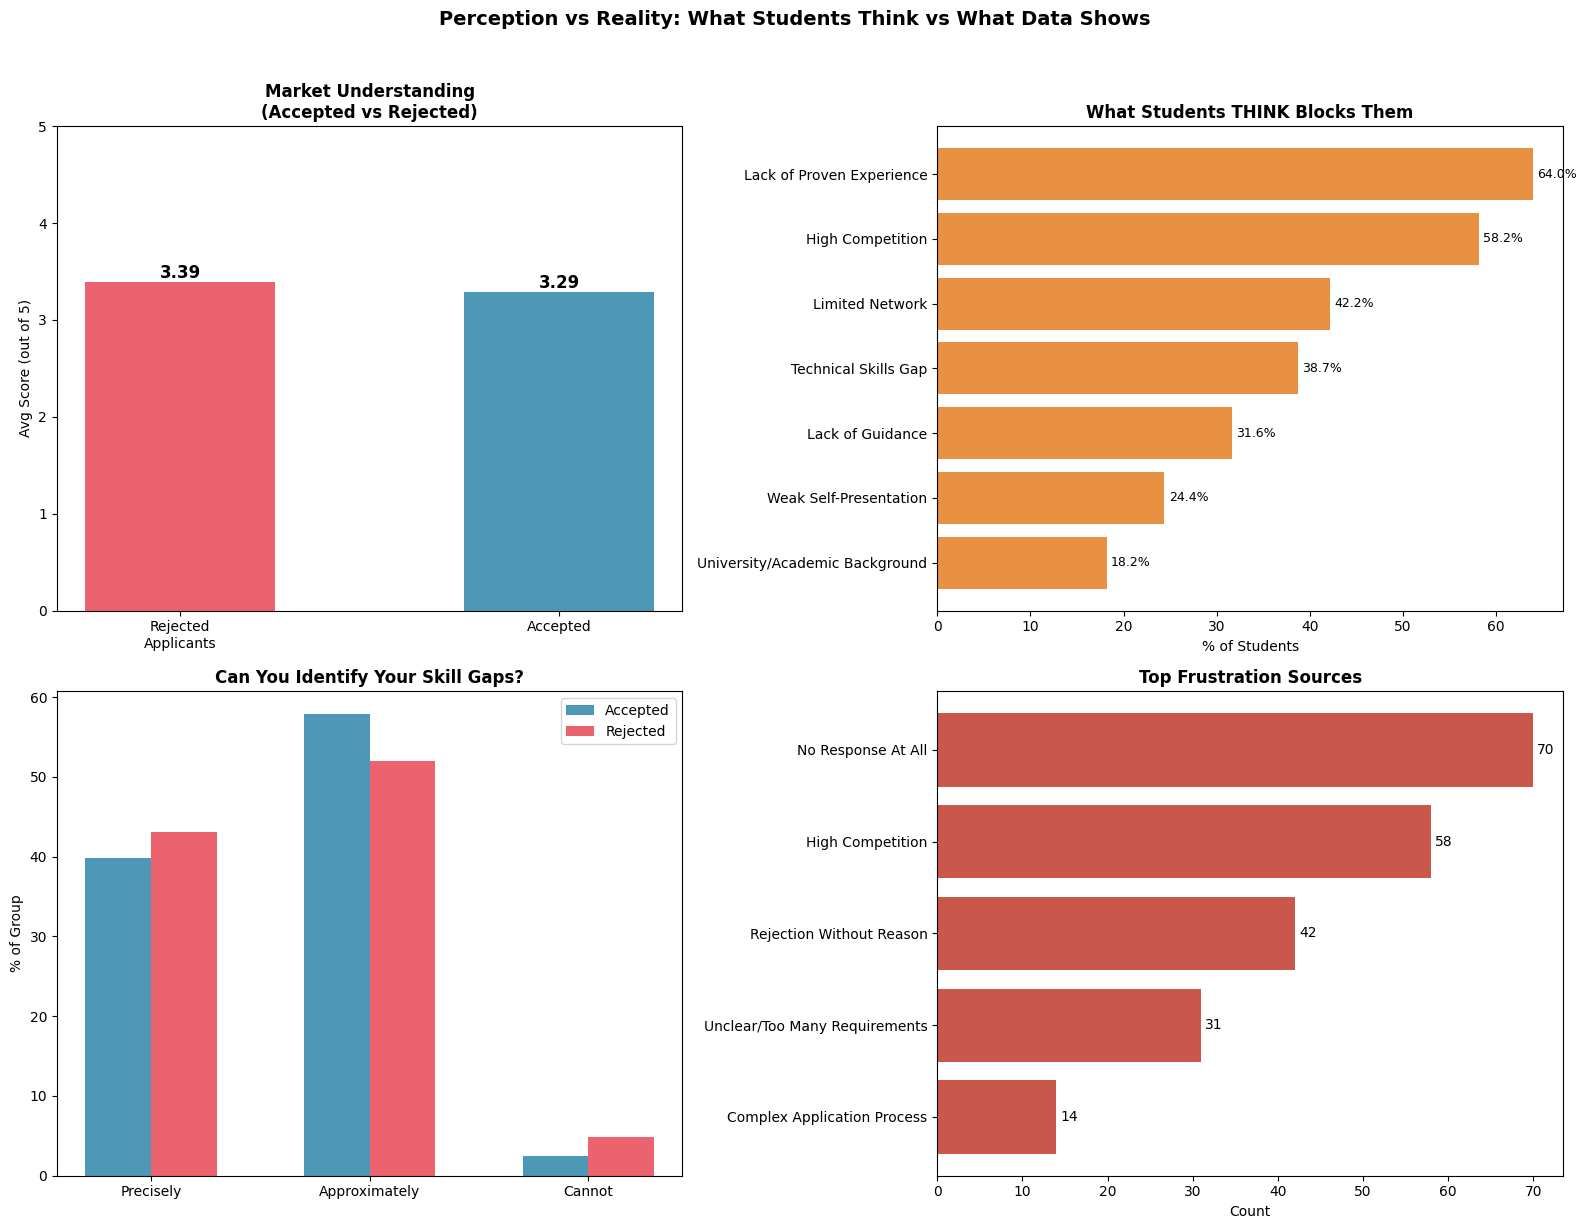

✅ perception_vs_reality.png

──────────────────────────────────────────────────────────────────────
F. SUCCESS PROFILE: Winners vs Losers
──────────────────────────────────────────────────────────────────────

Metric                Winners     Losers        Gap
----------------------------------------------------
Python                  65.9%      69.6%      -3.8%
SQL                     75.6%      79.4%      -3.8%
Excel                   92.7%      95.1%      -2.4%
Tableau                 41.5%      41.2%      +0.3%
Power BI                68.3%      82.4%     -14.1%
ML                      46.3%      56.9%     -10.5%
Portfolio               68.3%      73.5%      -5.2%
Mentor                  73.2%      63.7%      +9.4%
Kaggle                  14.6%      22.5%      -7.9%
Paid Training           46.3%      51.0%      -4.6%
Cairo                   39.0%      47.1%      -8.0%
Related Major           56.1%      71.6%     -15.5%


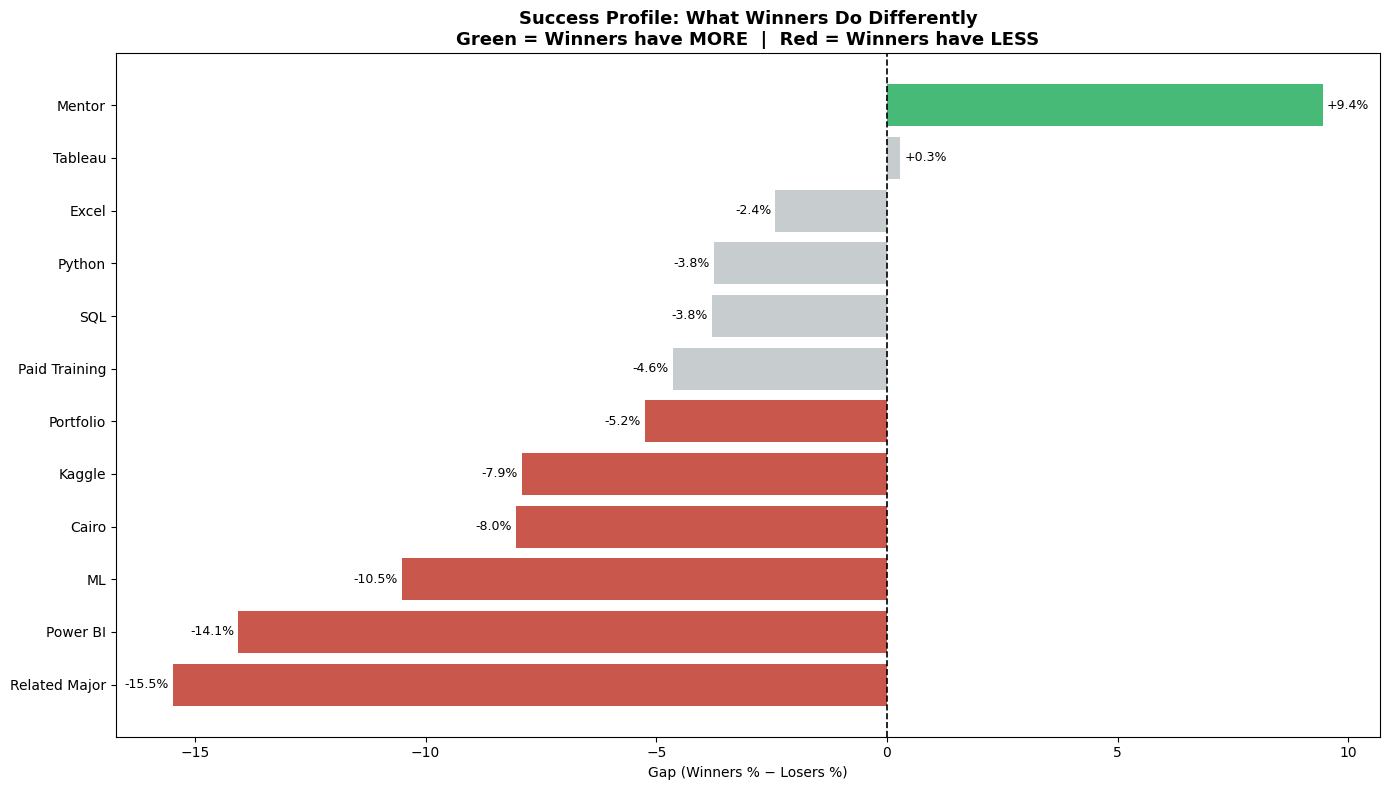

✅ success_profile.png

PHASE 5: ALL INSIGHTS SUMMARY
       Category                                                             Insight Impact                             Recommendation
         Funnel                               13.6% of skilled students never apply   HIGH Career counseling + job awareness programs
     Clustering                   4 distinct student personas identified via KMeans   HIGH         Tailored interventions per persona
Success Profile Winners vs losers differ most in mentor access and event attendance   HIGH    Structured mentorship + industry events
     Perception                 Top barrier perceived: lack of practical experience MEDIUM            Project-based learning programs
    Frustration                         Top frustration: no response from employers MEDIUM    Encourage companies to provide feedback

✅ PHASE 5 COMPLETE — ALL OUTPUT FILES:
  📁 conversion_funnel.csv
  📁 segment_analysis_results.csv
  📁 phase5_insights_summary.csv
  📊 conversi

In [6]:
# ============================================================
# PHASE 5: SEGMENTATION (KMeans + Perception Analysis)
# Uses exact Arabic strings from the real dataset
# FILE: student_data_FINAL_v3.xlsx (225 rows, 62 columns)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 0. LOAD ──────────────────────────────────────────────────
try:
    df = pd.read_excel('student_data_FINAL_v3.xlsx')
except:
    df = pd.read_csv('student_data_FINAL_v3.csv')

print("="*70)
print("PHASE 5: SEGMENTATION & DEEP INSIGHTS (KMeans + Perception)")
print("="*70)
print(f"Total students: {len(df)}")

# ── 1. ENSURE NUMERIC COLUMNS ────────────────────────────────
num_cols = [
    'accept_count_num', 'apps_count_num', 'projects_num',
    'learning_hours_num', 'has_mentor', 'has_portfolio_flag',
    'has_python', 'has_sql', 'has_excel', 'has_statistics',
    'has_tableau', 'has_powerbi', 'has_ml', 'has_any_viz_tool',
    'is_cairo', 'paid_training_flag', 'is_government_univ',
    'is_private_univ', 'events_num', 'has_kaggle', 'has_projects',
    'is_related_major', 'is_graduate', 'is_senior',
    'high_interview_readiness', 'tried_mentor', 'cant_afford', 'no_value'
]
for col in num_cols:
    if col in df.columns:
        if df[col].dtype in [bool, object]:
            df[col] = df[col].replace({True:1, False:0, 'True':1, 'False':0})
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

for col in ['interview_readiness', 'market_understanding']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['got_accepted'] = (df['accept_count_num'] > 0).astype(int)
df['applied'] = (df['apps_count_num'] > 0).astype(int)
total = len(df)


# ══════════════════════════════════════════════════════════════
# PART A: CONVERSION FUNNEL
# ══════════════════════════════════════════════════════════════
print("\n" + "─"*70)
print("A. CONVERSION FUNNEL")
print("─"*70)

has_skills = df[(df['has_python']==1) | (df['has_sql']==1) | (df['has_excel']==1)].shape[0]
applied_n  = df[df['apps_count_num'] > 0].shape[0]
accepted_n = df[df['accept_count_num'] > 0].shape[0]

funnel = pd.DataFrame({
    'Stage': ['Total Students', 'Has Basic Skills', 'Applied to Jobs', 'Got Accepted'],
    'Count': [total, has_skills, applied_n, accepted_n],
})
funnel['%'] = (funnel['Count'] / total * 100).round(1)
funnel['Drop_pct'] = [0] + [
    round((funnel['Count'].iloc[i-1] - funnel['Count'].iloc[i]) / funnel['Count'].iloc[i-1] * 100, 1)
    for i in range(1, len(funnel))
]
print(funnel.to_string(index=False))
funnel.to_csv('conversion_funnel.csv', index=False)

# Funnel chart
fig, ax = plt.subplots(figsize=(10, 5))
colors_f = ['#2E86AB', '#27AE60', '#E67E22', '#C0392B']
bars = ax.barh(funnel['Stage'][::-1], funnel['Count'][::-1], color=colors_f[::-1], height=0.55)
for bar, cnt, pct, drop in zip(bars, funnel['Count'][::-1], funnel['%'][::-1], funnel['Drop_pct'][::-1]):
    lbl = f'{cnt} ({pct}%)'
    if drop > 0: lbl += f'  [{drop}% drop]'
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2, lbl, va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Students'); ax.set_xlim(0, total*1.35)
ax.set_title('Application Conversion Funnel', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('conversion_funnel.png', dpi=300); plt.show()
print("✅ conversion_funnel.png")


# ══════════════════════════════════════════════════════════════
# PART B: KMEANS CLUSTERING (Gemini's suggestion — correct)
# ══════════════════════════════════════════════════════════════
print("\n" + "─"*70)
print("B. KMEANS CLUSTERING (Mutually Exclusive Segments)")
print("─"*70)

# Features for clustering
cluster_features = [
    'learning_hours_num', 'projects_num', 'apps_count_num', 'accept_count_num',
    'has_python', 'has_sql', 'has_excel', 'has_statistics',
    'has_tableau', 'has_powerbi', 'has_ml',
    'has_mentor', 'has_portfolio_flag', 'has_kaggle',
    'paid_training_flag', 'events_num', 'is_cairo'
]

X = df[cluster_features].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal K (Elbow method)
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Use K=4 (based on project needs)
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

# Profile each cluster
def profile_cluster(cluster_id, data):
    c = data[data['cluster'] == cluster_id]
    n = len(c)
    return {
        'Cluster': cluster_id,
        'Count': n,
        '% of Total': round(n/total*100, 1),
        'Avg Hours': round(c['learning_hours_num'].mean(), 1),
        'Avg Projects': round(c['projects_num'].mean(), 1),
        'Avg Apps': round(c['apps_count_num'].mean(), 1),
        'Avg Acceptances': round(c['accept_count_num'].mean(), 2),
        'Acceptance Rate': round(c['got_accepted'].mean()*100, 1),
        'Python %': round(c['has_python'].mean()*100, 1),
        'SQL %': round(c['has_sql'].mean()*100, 1),
        'Excel %': round(c['has_excel'].mean()*100, 1),
        'Tableau %': round(c['has_tableau'].mean()*100, 1),
        'Power BI %': round(c['has_powerbi'].mean()*100, 1),
        'ML %': round(c['has_ml'].mean()*100, 1),
        'Portfolio %': round(c['has_portfolio_flag'].mean()*100, 1),
        'Mentor %': round(c['has_mentor'].mean()*100, 1),
        'Kaggle %': round(c['has_kaggle'].mean()*100, 1),
        'Paid Training %': round(c['paid_training_flag'].mean()*100, 1),
        'Events': round(c['events_num'].mean(), 1),
        'Cairo %': round(c['is_cairo'].mean()*100, 1),
        'Interview Readiness': round(c['interview_readiness'].mean(), 1) if 'interview_readiness' in c.columns else 0,
        'Market Understanding': round(c['market_understanding'].mean(), 1) if 'market_understanding' in c.columns else 0,
    }

cluster_profiles = []
for i in range(K):
    p = profile_cluster(i, df)
    cluster_profiles.append(p)

profiles_df = pd.DataFrame(cluster_profiles)

# Auto-name clusters based on characteristics
for i, row in profiles_df.iterrows():
    if row['Acceptance Rate'] >= 50:
        profiles_df.loc[i, 'Persona'] = 'The Winners'
    elif row['Avg Hours'] >= 8 and row['Acceptance Rate'] < 30:
        profiles_df.loc[i, 'Persona'] = 'The Grinders (Effort ≠ Results)'
    elif row['Avg Apps'] < 3:
        profiles_df.loc[i, 'Persona'] = 'The Hesitant (Skilled but Passive)'
    else:
        profiles_df.loc[i, 'Persona'] = 'The Seekers (Average Effort)'

print("\n" + "="*70)
print("CLUSTER PROFILES:")
print("="*70)
for _, row in profiles_df.iterrows():
    print(f"\n--- Cluster {int(row['Cluster'])}: {row['Persona']} ---")
    print(f"  Size: {int(row['Count'])} ({row['% of Total']}%)")
    print(f"  Acceptance Rate: {row['Acceptance Rate']}%")
    print(f"  Avg Hours: {row['Avg Hours']} | Avg Projects: {row['Avg Projects']}")
    print(f"  Python: {row['Python %']}% | SQL: {row['SQL %']}% | Excel: {row['Excel %']}%")
    print(f"  Portfolio: {row['Portfolio %']}% | Mentor: {row['Mentor %']}%")
    print(f"  Cairo: {row['Cairo %']}% | Events: {row['Events']}")

profiles_df.to_csv('segment_analysis_results.csv', index=False)
print("\n✅ segment_analysis_results.csv")

# Map persona names back to main df
persona_map = profiles_df.set_index('Cluster')['Persona'].to_dict()
df['persona'] = df['cluster'].map(persona_map)


# ══════════════════════════════════════════════════════════════
# PART C: CLUSTER VISUALIZATION
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Phase 5: Student Personas (KMeans Clustering, K=4)',
             fontsize=16, fontweight='bold', y=1.01)

persona_colors = {'The Winners': '#27AE60',
                  'The Grinders (Effort ≠ Results)': '#C0392B',
                  'The Hesitant (Skilled but Passive)': '#E67E22',
                  'The Seekers (Average Effort)': '#3498DB'}

# Panel 1: Skills Radar (as grouped bars)
ax = axes[0, 0]
skill_metrics = ['Python %', 'SQL %', 'Excel %', 'Tableau %', 'Power BI %', 'ML %']
x_sk = np.arange(len(skill_metrics))
w = 0.8 / len(profiles_df)

for i, (_, row) in enumerate(profiles_df.iterrows()):
    vals = [row[m] for m in skill_metrics]
    color = persona_colors.get(row['Persona'], '#BDC3C7')
    ax.bar(x_sk + i*w, vals, w, label=row['Persona'], color=color, alpha=0.85)

ax.set_xticks(x_sk + w*(len(profiles_df)-1)/2)
ax.set_xticklabels([m.replace(' %', '') for m in skill_metrics], fontsize=9)
ax.set_ylabel('% of Cluster')
ax.set_title('Skills by Persona', fontweight='bold')
ax.legend(fontsize=7, loc='upper right')

# Panel 2: Behaviors
ax = axes[0, 1]
behav_metrics = ['Portfolio %', 'Mentor %', 'Kaggle %', 'Paid Training %']
x_bh = np.arange(len(behav_metrics))

for i, (_, row) in enumerate(profiles_df.iterrows()):
    vals = [row.get(m, 0) for m in behav_metrics]
    color = persona_colors.get(row['Persona'], '#BDC3C7')
    ax.bar(x_bh + i*w, vals, w, color=color, alpha=0.85)

ax.set_xticks(x_bh + w*(len(profiles_df)-1)/2)
ax.set_xticklabels([m.replace(' %', '') for m in behav_metrics], fontsize=9)
ax.set_ylabel('% of Cluster')
ax.set_title('Behaviors by Persona', fontweight='bold')

# Panel 3: Effort vs Outcome scatter
ax = axes[1, 0]
for persona, group in df.groupby('persona'):
    color = persona_colors.get(persona, '#BDC3C7')
    ax.scatter(group['learning_hours_num'], group['accept_count_num'],
               label=persona, color=color, alpha=0.5, s=40)
ax.set_xlabel('Learning Hours/Week')
ax.set_ylabel('Acceptances')
ax.set_title('Effort vs Outcome by Persona', fontweight='bold')
ax.legend(fontsize=7)

# Panel 4: Acceptance Rate per Persona
ax = axes[1, 1]
persona_order = profiles_df.sort_values('Acceptance Rate', ascending=True)
bar_colors = [persona_colors.get(p, '#BDC3C7') for p in persona_order['Persona']]
bars_acc = ax.barh(persona_order['Persona'], persona_order['Acceptance Rate'],
                    color=bar_colors, alpha=0.85)
ax.bar_label(bars_acc, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')
ax.set_xlabel('Acceptance Rate (%)')
ax.set_title('Acceptance Rate by Persona', fontweight='bold')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('segment_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ segment_comparison.png")


# ══════════════════════════════════════════════════════════════
# PART D: PERCEPTION VS REALITY (Using exact Arabic strings)
# ══════════════════════════════════════════════════════════════
print("\n" + "─"*70)
print("D. PERCEPTION VS REALITY ANALYSIS")
print("─"*70)

accepted = df[df['got_accepted'] == 1]
rejected_applicants = df[(df['apps_count_num'] > 0) & (df['got_accepted'] == 0)]

# D1: Requirements Clarity
# Exact values: واضحة جدًا وعارف أقيس نفسي عليها | واضحة لكن مش عارف أحدد موقفي
#               بتختلف من فرصة للتانية | غير واضحة ومبهمة
if 'requirements_clarity' in df.columns:
    print("\n--- Requirements Clarity ---")
    rc = df['requirements_clarity'].value_counts(dropna=False)
    for val, cnt in rc.items():
        print(f"  [{cnt:3d}] {val}")

# D2: Can Identify Gaps
# Exact values: نعم بدقة | تقريبا | لا
if 'can_identify_gaps' in df.columns:
    print("\n--- Can Identify Gaps (Accepted vs Rejected) ---")
    for label, grp in [('Accepted', accepted), ('Rejected (applicants)', rejected_applicants)]:
        precise = grp['can_identify_gaps'].astype(str).str.contains('نعم بدقة', na=False).mean()*100
        approx = grp['can_identify_gaps'].astype(str).str.contains('تقريبا', na=False).mean()*100
        no_val = grp['can_identify_gaps'].astype(str).str.contains('^لا$', na=False, regex=True).mean()*100
        print(f"  {label}: Precise={precise:.1f}%, Approx={approx:.1f}%, No={no_val:.1f}%")

# D3: Perceived Barriers (multi-select with exact strings)
if 'perceived_barriers' in df.columns:
    print("\n--- Perceived Barriers (All Students) ---")
    barrier_options = {
        'نقص مهارات تقنية محددة': 'Technical Skills Gap',
        'نقص خبرة عملية مثبتة': 'Lack of Proven Experience',
        'ضعف في عرض نفسي': 'Weak Self-Presentation',
        'قلة توجيه أو عدم وضوح متطلبات السوق': 'Lack of Guidance',
        'منافسة عالية جدًا': 'High Competition',
        'نوع الجامعة أو الخلفية الأكاديمية': 'University/Academic Background',
        'شبكة علاقات محدودة': 'Limited Network',
    }

    barrier_data = []
    pb_str = df['perceived_barriers'].astype(str)
    for ar_text, en_label in barrier_options.items():
        count = pb_str.str.contains(ar_text, na=False).sum()
        pct = count / total * 100
        print(f"  {en_label}: {count} ({pct:.1f}%)")
        barrier_data.append({'Barrier': en_label, 'Barrier_AR': ar_text, 'Count': count, '%': round(pct, 1)})

    barrier_df = pd.DataFrame(barrier_data).sort_values('Count', ascending=False)

# D4: Frustration Sources (multi-select with exact strings)
if 'frustration_sources' in df.columns:
    print("\n--- Frustration Sources ---")
    frust_options = {
        'عدم الرد تمامًا': 'No Response At All',
        'رفض بدون توضيح سبب': 'Rejection Without Reason',
        'منافسة عالية جدًا': 'High Competition',
        'متطلبات كتير ومش واضحة': 'Unclear/Too Many Requirements',
        'عملية تقديم معقدة': 'Complex Application Process',
    }

    frust_data = []
    fs_str = df['frustration_sources'].astype(str)
    for ar_text, en_label in frust_options.items():
        count = fs_str.str.contains(ar_text, na=False).sum()
        pct = count / total * 100
        print(f"  {en_label}: {count} ({pct:.1f}%)")
        frust_data.append({'Frustration': en_label, 'Count': count, '%': round(pct, 1)})

    frust_df = pd.DataFrame(frust_data).sort_values('Count', ascending=False)

# D5: Biggest Challenge
if 'biggest_challenge' in df.columns:
    print("\n--- Biggest Challenge ---")
    bc = df['biggest_challenge'].value_counts()
    for val, cnt in bc.items():
        print(f"  [{cnt:3d}] {val}")

# D6: Info Sources
if 'info_sources' in df.columns:
    print("\n--- Info Sources ---")
    info_options = {
        'LinkedIn': 'LinkedIn',
        'فيسبوك': 'Facebook Groups',
        'جروبات فيسبوك': 'Facebook Groups',
        'الجامعة': 'University',
        'أصدقاء': 'Friends/Connections',
        'مواقع توظيف': 'Job Platforms',
    }

    is_str = df['info_sources'].astype(str)
    info_data = {}
    for ar_text, en_label in info_options.items():
        count = is_str.str.contains(ar_text, na=False).sum()
        if en_label in info_data:
            info_data[en_label] = max(info_data[en_label], count)
        else:
            info_data[en_label] = count

    for label, count in sorted(info_data.items(), key=lambda x: x[1], reverse=True):
        print(f"  {label}: {count} ({count/total*100:.1f}%)")


# ══════════════════════════════════════════════════════════════
# PART E: PERCEPTION VS REALITY VISUALIZATION
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perception vs Reality: What Students Think vs What Data Shows',
             fontsize=14, fontweight='bold', y=1.02)

# Panel 1: Market Understanding (accepted vs rejected)
ax = axes[0, 0]
if 'market_understanding' in df.columns:
    mu_acc = accepted['market_understanding'].mean()
    mu_rej = rejected_applicants['market_understanding'].mean()
    bars_mu = ax.bar(['Rejected\nApplicants', 'Accepted'], [mu_rej, mu_acc],
                     color=['#E84855', '#2E86AB'], alpha=0.85, width=0.5)
    ax.bar_label(bars_mu, fmt='%.2f', fontsize=12, fontweight='bold')
    ax.set_ylabel('Avg Score (out of 5)')
    ax.set_title('Market Understanding\n(Accepted vs Rejected)', fontweight='bold')
    ax.set_ylim(0, 5)

# Panel 2: Perceived Barriers
ax = axes[0, 1]
if len(barrier_data) > 0:
    bdf = barrier_df.head(7)
    bars_b = ax.barh(bdf['Barrier'], bdf['%'], color='#E67E22', alpha=0.85)
    ax.bar_label(bars_b, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_xlabel('% of Students')
    ax.set_title('What Students THINK Blocks Them', fontweight='bold')
    ax.invert_yaxis()

# Panel 3: Can Identify Gaps (accepted vs rejected)
ax = axes[1, 0]
if 'can_identify_gaps' in df.columns:
    gap_labels = ['Precisely', 'Approximately', 'Cannot']
    gap_keywords = ['نعم بدقة', 'تقريبا', 'لا']

    acc_vals = [accepted['can_identify_gaps'].astype(str).str.contains(kw, na=False).mean()*100
                for kw in gap_keywords]
    rej_vals = [rejected_applicants['can_identify_gaps'].astype(str).str.contains(kw, na=False).mean()*100
                for kw in gap_keywords]

    x_g = np.arange(3)
    ax.bar(x_g - 0.15, acc_vals, 0.3, label='Accepted', color='#2E86AB', alpha=0.85)
    ax.bar(x_g + 0.15, rej_vals, 0.3, label='Rejected', color='#E84855', alpha=0.85)
    ax.set_xticks(x_g); ax.set_xticklabels(gap_labels)
    ax.set_ylabel('% of Group')
    ax.set_title('Can You Identify Your Skill Gaps?', fontweight='bold')
    ax.legend()

# Panel 4: Frustration Sources
ax = axes[1, 1]
if len(frust_data) > 0:
    fdf = frust_df.head(5)
    bars_fr = ax.barh(fdf['Frustration'], fdf['Count'], color='#C0392B', alpha=0.85)
    ax.bar_label(bars_fr, fmt='%d', padding=3)
    ax.set_xlabel('Count')
    ax.set_title('Top Frustration Sources', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('perception_vs_reality.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ perception_vs_reality.png")


# ══════════════════════════════════════════════════════════════
# PART F: SUCCESS PROFILE (Winners vs Losers)
# ══════════════════════════════════════════════════════════════
print("\n" + "─"*70)
print("F. SUCCESS PROFILE: Winners vs Losers")
print("─"*70)

winners = df[df['accept_count_num'] >= 2]
losers  = df[(df['apps_count_num'] > 0) & (df['accept_count_num'] == 0)]

metrics_compare = {
    'Python':       'has_python',
    'SQL':          'has_sql',
    'Excel':        'has_excel',
    'Tableau':      'has_tableau',
    'Power BI':     'has_powerbi',
    'ML':           'has_ml',
    'Portfolio':    'has_portfolio_flag',
    'Mentor':       'has_mentor',
    'Kaggle':       'has_kaggle',
    'Paid Training':'paid_training_flag',
    'Cairo':        'is_cairo',
    'Related Major':'is_related_major',
}

profile_rows = []
print(f"\n{'Metric':<18} {'Winners':>10} {'Losers':>10} {'Gap':>10}")
print("-"*52)
for name, col in metrics_compare.items():
    if col in df.columns:
        w = winners[col].mean() * 100
        l = losers[col].mean() * 100
        gap = w - l
        print(f"{name:<18} {w:>9.1f}% {l:>9.1f}% {gap:>+9.1f}%")
        profile_rows.append({'Metric': name, 'Winners %': w, 'Losers %': l, 'Gap': gap})

profile_df = pd.DataFrame(profile_rows).sort_values('Gap', ascending=True)

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))
colors_p = ['#27AE60' if g > 5 else '#C0392B' if g < -5 else '#BDC3C7' for g in profile_df['Gap']]
bars_sp = ax.barh(profile_df['Metric'], profile_df['Gap'], color=colors_p, alpha=0.85)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.bar_label(bars_sp, fmt='%+.1f%%', padding=3, fontsize=9)
ax.set_xlabel('Gap (Winners % − Losers %)')
ax.set_title('Success Profile: What Winners Do Differently\n'
             'Green = Winners have MORE  |  Red = Winners have LESS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('success_profile.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ success_profile.png")


# ══════════════════════════════════════════════════════════════
# PART G: INSIGHTS SUMMARY
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PHASE 5: ALL INSIGHTS SUMMARY")
print("="*70)

insights = [
    {'Category': 'Funnel',
     'Insight': f'{round((has_skills-applied_n)/has_skills*100,1)}% of skilled students never apply',
     'Impact': 'HIGH',
     'Recommendation': 'Career counseling + job awareness programs'},
    {'Category': 'Clustering',
     'Insight': f'{K} distinct student personas identified via KMeans',
     'Impact': 'HIGH',
     'Recommendation': 'Tailored interventions per persona'},
    {'Category': 'Success Profile',
     'Insight': 'Winners vs losers differ most in mentor access and event attendance',
     'Impact': 'HIGH',
     'Recommendation': 'Structured mentorship + industry events'},
    {'Category': 'Perception',
     'Insight': 'Top barrier perceived: lack of practical experience',
     'Impact': 'MEDIUM',
     'Recommendation': 'Project-based learning programs'},
    {'Category': 'Frustration',
     'Insight': 'Top frustration: no response from employers',
     'Impact': 'MEDIUM',
     'Recommendation': 'Encourage companies to provide feedback'},
]

insights_df = pd.DataFrame(insights)
insights_df.to_csv('phase5_insights_summary.csv', index=False)
print(insights_df.to_string(index=False))


# ══════════════════════════════════════════════════════════════
# FINAL OUTPUT LIST
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("✅ PHASE 5 COMPLETE — ALL OUTPUT FILES:")
print("="*70)
print("  📁 conversion_funnel.csv")
print("  📁 segment_analysis_results.csv")
print("  📁 phase5_insights_summary.csv")
print("  📊 conversion_funnel.png")
print("  📊 segment_comparison.png")
print("  📊 perception_vs_reality.png")
print("  📊 success_profile.png")
print("="*70)

